<a href="https://colab.research.google.com/github/vvluo/time_series_copy/blob/main/Time_Series_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fredapi


In [ ]:
from fredapi import Fred
import pandas as pd
import numpy as np

API_KEY = "99e2795526372f07eb841dccbc8421f1"
fred = Fred(api_key=API_KEY)

In [ ]:
unrate = fred.get_series('UNRATE',
                         observation_start='1954-07-01',  # optional
                         observation_end='2019-12-01')    # optional
unrate = unrate.dropna()
unrate.name = 'UNRATE'

print(unrate.head())
df_u = unrate.to_frame().reset_index()
df_u.columns = ['date','unrate']
print(df_u.tail())

1954-07-01    5.8
1954-08-01    6.0
1954-09-01    6.1
1954-10-01    5.7
1954-11-01    5.3
Name: UNRATE, dtype: float64
          date  unrate
781 2019-08-01     3.6
782 2019-09-01     3.5
783 2019-10-01     3.6
784 2019-11-01     3.6
785 2019-12-01     3.6


In [ ]:
cpi = fred.get_series('CPIAUCSL',
                      observation_start='1954-07-01',  # optional
                         observation_end='2019-12-01')    # optional
cpi = cpi.dropna()
cpi.name='CPI'
lcpi = np.log(cpi)
print(lcpi.head())
df_c = lcpi.to_frame().reset_index()
df_c.columns = ['date','lcpi']
print(df_c.tail())

1954-07-01    3.290638
1954-08-01    3.290266
1954-09-01    3.288775
1954-10-01    3.285412
1954-11-01    3.287655
Name: CPI, dtype: float64
          date      lcpi
781 2019-08-01  5.545318
782 2019-09-01  5.546856
783 2019-10-01  5.549679
784 2019-11-01  5.552490
785 2019-12-01  5.555398


In [ ]:
ffr = fred.get_series('FEDFUNDS',
                      observation_start='1954-07-01',  # optional
                         observation_end='2019-12-01')    # optional
ffr = ffr.dropna()
ffr.name = 'FFR'
print(ffr.head())
df_f = ffr.to_frame().reset_index()
df_f.columns = ['date', 'ffr']
print(df_f.tail())

1954-07-01    0.80
1954-08-01    1.22
1954-09-01    1.07
1954-10-01    0.85
1954-11-01    0.83
Name: FFR, dtype: float64
          date   ffr
781 2019-08-01  2.13
782 2019-09-01  2.04
783 2019-10-01  1.83
784 2019-11-01  1.55
785 2019-12-01  1.55


# Time Series Regression
Predicting
* UNRATE

Regressors
* Lags of UNRATE l=1,2,3,4
* (n=10) day rolling average of UNRATE trend sign

# Task
Build a time series regression model to predict the 'UNRATE' series, using its lags (l=1, 2, 3, 4) and a 10-day rolling average of its trend sign as regressors. Train a Linear Regression model, evaluate its performance using Mean Squared Error (MSE), and ensure proper data preparation, including handling NaNs, feature scaling, and train-test splitting.

## Generate Lags

### Subtask:
Create lagged features (l=1, 2, 3, 4) for the UNRATE series.


**Reasoning**:
The subtask requires creating lagged features for the 'unrate' column in the `df_u` DataFrame. I will add four new columns for lags 1 through 4 using the `.shift()` method.



In [ ]:
L = 2
for i in range(1, L):
    df_u[f'UNRATE_Lag_{i}'] = df_u['unrate'].shift(i)

for j in range(12, 4*12, 12):
    df_u[f'UNRATE_Lag_{j}'] = df_u['unrate'].shift(j)

print(df_u.head())

CL = 1
for i in range(1, CL):
    df_c[f'LOGCPI_Lag_{i}'] = df_c['lcpi'].shift(i)

print(df_c.head())

FL = 1
for i in range(1, FL):
    df_f[f'FEDFUNDS_Lag_{i}'] = df_f['ffr'].shift(i)

print(df_f.head())

        date  unrate  UNRATE_Lag_1  unrate_diff  Rolling_Trend  UNRATE_Lag_12  \
0 1954-07-01     5.8           NaN          NaN            NaN            NaN   
1 1954-08-01     6.0           5.8          0.2            NaN            NaN   
2 1954-09-01     6.1           6.0          0.1       0.200000            NaN   
3 1954-10-01     5.7           6.1         -0.4       0.181818            NaN   
4 1954-11-01     5.3           5.7         -0.4       0.076033            NaN   

   UNRATE_Lag_24  UNRATE_Lag_36  
0            NaN            NaN  
1            NaN            NaN  
2            NaN            NaN  
3            NaN            NaN  
4            NaN            NaN  
        date      lcpi
0 1954-07-01  3.290638
1 1954-08-01  3.290266
2 1954-09-01  3.288775
3 1954-10-01  3.285412
4 1954-11-01  3.287655
        date   ffr
0 1954-07-01  0.80
1 1954-08-01  1.22
2 1954-09-01  1.07
3 1954-10-01  0.85
4 1954-11-01  0.83


## Calculate Rolling Trend Sign

### Subtask:
Calculate the 10-day rolling average of the UNRATE trend sign.


**Reasoning**:
First, I need to calculate the daily difference of the 'unrate' column to determine the trend. This is the first step in creating the trend sign feature as per the instructions.



In [ ]:
df_u['unrate_diff'] = df_u['unrate'].diff()

In [ ]:
df_u['Rolling_Trend'] = df_u['unrate_diff'].ewm(span=10, adjust=False).mean().shift(1)

**Reasoning**:
Now that the daily difference has been calculated, I will determine the sign of this difference using `np.sign()`, assigning `1` for an increase, `-1` for a decrease, and `0` for no change. I will import numpy to use `np.sign()`.



In [ ]:
import numpy as np
df_u['unrate_trend_sign'] = np.sign(df_u['unrate_diff'])

**Reasoning**:
Following the instructions, I will now calculate the 10-period rolling average of the 'unrate_trend_sign' column using a window of 10 and then store the result in a new column named 'Rolling_Trend_Sign'.



In [ ]:
df_u['Rolling_Trend_Sign'] = df_u['unrate_trend_sign'].ewm(span=10, adjust=False).mean().shift(1)

print(df_u.head(15))

         date  unrate  unrate_diff  Rolling_Trend  unrate_trend_sign  \
0  1954-07-01     5.8          NaN            NaN                NaN   
1  1954-08-01     6.0          0.2            NaN                1.0   
2  1954-09-01     6.1          0.1       0.200000                1.0   
3  1954-10-01     5.7         -0.4       0.181818               -1.0   
4  1954-11-01     5.3         -0.4       0.076033               -1.0   
5  1954-12-01     5.0         -0.3      -0.010518               -1.0   
6  1955-01-01     4.9         -0.1      -0.063151               -1.0   
7  1955-02-01     4.7         -0.2      -0.069851               -1.0   
8  1955-03-01     4.6         -0.1      -0.093515               -1.0   
9  1955-04-01     4.7          0.1      -0.094694                1.0   
10 1955-05-01     4.3         -0.4      -0.059295               -1.0   
11 1955-06-01     4.2         -0.1      -0.121241               -1.0   
12 1955-07-01     4.0         -0.2      -0.117379               

## Calculate Rolling Trend Sign for Second Difference

### Subtask:
Calculate the 10-day rolling average of the second difference's trend sign for the UNRATE series.

**Reasoning**:
First, I need to calculate the second difference of the 'unrate' column to determine its change in trend. This is done by applying the `.diff()` method twice.

In [ ]:
df_u['unrate_diff2'] = df_u['unrate'].diff().diff()

In [ ]:
df_u['Rolling_Trend2'] = df_u['unrate_diff2'].ewm(span=10, adjust=False).mean().shift(1)

**Reasoning**:
Now that the second difference has been calculated, I will determine the sign of this difference using `np.sign()`, assigning `1` for an increase, `-1` for a decrease, and `0` for no change in the second difference trend.

In [ ]:
df_u['unrate_trend_sign2'] = np.sign(df_u['unrate_diff2'])

**Reasoning**:
Finally, I will calculate the 10-period rolling average of the `unrate_trend_sign2` column using a window of 10 and store the result in a new column named 'Rolling_Trend_Sign2'.

In [ ]:
df_u['Rolling_Trend_Sign2'] = df_u['unrate_trend_sign2'].ewm(span=10, adjust=False).mean().shift(1)

print(df_u.head(15))

         date  unrate  UNRATE_Lag_1  unrate_diff  Rolling_Trend  \
0  1954-07-01     5.8           NaN          NaN            NaN   
1  1954-08-01     6.0           5.8          0.2            NaN   
2  1954-09-01     6.1           6.0          0.1       0.200000   
3  1954-10-01     5.7           6.1         -0.4       0.181818   
4  1954-11-01     5.3           5.7         -0.4       0.076033   
5  1954-12-01     5.0           5.3         -0.3      -0.010518   
6  1955-01-01     4.9           5.0         -0.1      -0.063151   
7  1955-02-01     4.7           4.9         -0.2      -0.069851   
8  1955-03-01     4.6           4.7         -0.1      -0.093515   
9  1955-04-01     4.7           4.6          0.1      -0.094694   
10 1955-05-01     4.3           4.7         -0.4      -0.059295   
11 1955-06-01     4.2           4.3         -0.1      -0.121241   
12 1955-07-01     4.0           4.2         -0.2      -0.117379   
13 1955-08-01     4.2           4.0          0.2      -0.13240

# Calculate Log-CPI Rolling Trend



In [ ]:
df_c['lcpi_diff'] = df_c['lcpi'].diff()
df_c['Rolling_LCPI_Trend'] = df_c['lcpi_diff'].ewm(span=10, adjust=False).mean().shift(1)

print(df_c.head(15))

         date      lcpi  lcpi_diff  Rolling_LCPI_Trend
0  1954-07-01  3.290638        NaN                 NaN
1  1954-08-01  3.290266  -0.000372                 NaN
2  1954-09-01  3.288775  -0.001491           -0.000372
3  1954-10-01  3.285412  -0.003363           -0.000576
4  1954-11-01  3.287655   0.002243           -0.001082
5  1954-12-01  3.287282  -0.000373           -0.000478
6  1955-01-01  3.287282   0.000000           -0.000459
7  1955-02-01  3.289148   0.001866           -0.000375
8  1955-03-01  3.288029  -0.001119            0.000032
9  1955-04-01  3.288029   0.000000           -0.000177
10 1955-05-01  3.287282  -0.000747           -0.000145
11 1955-06-01  3.285038  -0.002244           -0.000254
12 1955-07-01  3.286908   0.001870           -0.000616
13 1955-08-01  3.285412  -0.001496           -0.000164
14 1955-09-01  3.290266   0.004853           -0.000406


# Calculate FFR Rolling Trend

In [ ]:
df_f['ffr_diff'] = df_f['ffr'].diff()
df_f['Rolling_FFR_Trend'] = df_f['ffr_diff'].ewm(span=10, adjust=False).mean().shift(1)

print(df_f.head(15))

         date   ffr  ffr_diff  Rolling_FFR_Trend
0  1954-07-01  0.80       NaN                NaN
1  1954-08-01  1.22      0.42                NaN
2  1954-09-01  1.07     -0.15           0.420000
3  1954-10-01  0.85     -0.22           0.316364
4  1954-11-01  0.83     -0.02           0.218843
5  1954-12-01  1.28      0.45           0.175417
6  1955-01-01  1.39      0.11           0.225341
7  1955-02-01  1.29     -0.10           0.204370
8  1955-03-01  1.35      0.06           0.149030
9  1955-04-01  1.43      0.08           0.132843
10 1955-05-01  1.43      0.00           0.123235
11 1955-06-01  1.64      0.21           0.100829
12 1955-07-01  1.68      0.04           0.120678
13 1955-08-01  1.96      0.28           0.106009
14 1955-09-01  2.18      0.22           0.137644


# Regression
## Prepare Data for Regression

### Subtask:
Combine UNRATE and the generated regressors into a single DataFrame, handle NaNs, and split into features (X) and target (y).


**Reasoning**:
I will create a DataFrame `X` with the specified feature columns and a Series `y` with the target variable 'unrate' from `df_u`.



In [ ]:
# column_names = [f'UNRATE_Lag_{i}' for i in range(1,L)]
column_names = [f'UNRATE_Lag_{i}' for i in range(1,L)] + [f'UNRATE_Lag_{i}' for i in range(12,12*4,12)]
c_column_names = [f'LOGCPI_Lag_{i}' for i in range(1, CL)]
f_column_names = [f'FEDFUNDS_Lag_{i}' for i in range(1,FL)]
# no rolling trends
# X = pd.concat([df_u[column_names], df_c[c_column_names], df_f[f_column_names]], axis=1)
# no exterior rolling trends
X = pd.concat([df_u[column_names + ['Rolling_Trend']], df_c[c_column_names], df_f[f_column_names]], axis=1)
# exterior rolling trend: Log CPI
# X = pd.concat([df_u[column_names + ['Rolling_Trend']], df_c[c_column_names + ['Rolling_LCPI_Trend']], df_f[f_column_names]], axis=1)
# exterior rolling trend: FFR
# X = pd.concat([df_u[column_names + ['Rolling_Trend']], df_c[c_column_names], df_f[f_column_names + ['Rolling_FFR_Trend']]], axis=1)
# exterior rolling trend: both
# X = pd.concat([df_u[column_names + ['Rolling_Trend']], df_c[c_column_names + ['Rolling_LCPI_Trend']], df_f[f_column_names + ['Rolling_FFR_Trend']]], axis=1)
y = df_u['unrate']

print("Features (X) head:\n", X.head())
print("Target (y) head:\n", y.head())

Features (X) head:
    UNRATE_Lag_1  UNRATE_Lag_12  UNRATE_Lag_24  UNRATE_Lag_36  Rolling_Trend
0           NaN            NaN            NaN            NaN            NaN
1           5.8            NaN            NaN            NaN            NaN
2           6.0            NaN            NaN            NaN       0.200000
3           6.1            NaN            NaN            NaN       0.181818
4           5.7            NaN            NaN            NaN       0.076033
Target (y) head:
 0    5.8
1    6.0
2    6.1
3    5.7
4    5.3
Name: unrate, dtype: float64


**Reasoning**:
I will drop any rows with NaN values from both `X` and `y` to ensure the regression model receives clean data, and then reindex `y` to align with `X` after the NaN values are dropped.



In [ ]:
X = X.dropna()
# X = X[31:]
y = y.reindex(X.index)

print("Features (X) head after dropping NaNs:\n", X.head())
print("Target (y) head after dropping NaNs:\n", y.head())
print("Shape of X after dropping NaNs:", X.shape)
print("Shape of y after dropping NaNs:", y.shape)

Features (X) head after dropping NaNs:
     UNRATE_Lag_1  UNRATE_Lag_12  UNRATE_Lag_24  UNRATE_Lag_36  Rolling_Trend
36           4.3            4.4            4.0            5.8       0.048884
37           4.2            4.1            4.2            6.0       0.021814
38           4.1            3.9            4.1            6.1      -0.000334
39           4.4            3.9            4.3            5.7       0.054272
40           4.5            4.3            4.2            5.3       0.062586
Target (y) head after dropping NaNs:
 36    4.2
37    4.1
38    4.4
39    4.5
40    5.1
Name: unrate, dtype: float64
Shape of X after dropping NaNs: (750, 5)
Shape of y after dropping NaNs: (750,)


## Train-Test Split

### Subtask:
Split the data into training and testing sets.


**Reasoning**:
I will import the `train_test_split` function and then split the `X` and `y` data into training and testing sets with an 80/20 ratio and a fixed random state for reproducibility.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (600, 5)
Shape of X_test: (150, 5)
Shape of y_train: (600,)
Shape of y_test: (150,)


## Feature Scaling

### Subtask:
Scale the features using `StandardScaler` to normalize the data.


**Reasoning**:
I will import `StandardScaler` from `sklearn.preprocessing`, initialize it, fit it on the training features (`X_train`), and then transform both the training and testing features (`X_train` and `X_test`) to scale them. This ensures that all features contribute equally to the model.



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("First 5 rows of X_train_scaled:\n", X_train_scaled[:5])

Shape of X_train_scaled: (600, 5)
Shape of X_test_scaled: (150, 5)
First 5 rows of X_train_scaled:
 [[-1.09297358 -1.01028967 -1.26838094 -0.02113539  0.5549202 ]
 [-1.1631785  -1.21953157 -1.13012523  0.11670412  0.24254658]
 [-1.23338342 -1.35902618 -1.19925309  0.18562388 -0.01303184]
 [-1.02276866 -1.35902618 -1.06099738 -0.09005515  0.61709828]
 [-0.95256374 -1.08003697 -1.13012523 -0.36573418  0.71303942]]


## Train Linear Regression Model

### Subtask:
Train a Linear Regression model using the scaled training data.

**Reasoning**:
I will import `LinearRegression` from `sklearn.linear_model`, initialize the model, and then fit it to the scaled training data (`X_train_scaled`, `y_train`).



In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained Linear Regression model using Mean Squared Error (MSE) on the test data.

**Reasoning**:
Now that the model has been trained, I will make predictions on the scaled test data and then calculate the Mean Squared Error (MSE) to evaluate the model's performance.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

y_pred_train = model.predict(X_train_scaled)
n = len(y_train)
k = X_train_scaled.shape[1] + 1                # p regressors + intercept
RSS = np.sum((y_train - y_pred_train)**2)

AIC = n * np.log(RSS / n) + 2 * k
print("AIC:", AIC)

y_pred = model.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Root Mean Squared Error on the test set: {rmse:.4f}")
print(f"Mean Absolute Error on the test set: {mae:.4f}")

AIC: -2069.327770129018
Root Mean Squared Error on the test set: 0.1591
Mean Absolute Error on the test set: 0.1271


In [ ]:
import statsmodels.api as sm

# Add intercept to the scaled training data
X_train_scaled_with_intercept = sm.add_constant(X_train_scaled)

# Create an OLS model object
model_ols = sm.OLS(y_train, X_train_scaled_with_intercept)

# Fit the OLS model
results = model_ols.fit()

# Get coefficients and standard errors
coefficients = results.params
std_errors = results.bse
t_values = results.tvalues

# Get original feature names from X
original_feature_names = list(X.columns)

# Create a mapping from 'x1', 'x2', etc. to original feature names
rename_map = {'const': 'const'}
for i, col_name in enumerate(original_feature_names):
    rename_map[f'x{i+1}'] = col_name

# Rename the indices of the Series to match the original feature names
coefficients = coefficients.rename(index=rename_map)
std_errors = std_errors.rename(index=rename_map)
t_values = t_values.rename(index=rename_map)

# Create a DataFrame to display the results
summary_df = pd.DataFrame({
    'Coefficient': coefficients,
    'Standard Error': std_errors,
    'T-value': t_values
})

print("\nModel Coefficients and T-scores:")
print(summary_df)


Model Coefficients and T-scores:
               Coefficient  Standard Error     T-value
const             5.857333        0.007242  808.817986
UNRATE_Lag_1      1.351078        0.027474   49.176235
UNRATE_Lag_12     0.035326        0.029205    1.209596
UNRATE_Lag_24     0.015321        0.014162    1.081844
UNRATE_Lag_36    -0.000957        0.010766   -0.088862
Rolling_Trend     0.090663        0.019134    4.738187


## Summary:

### Q&A
The time series regression model, a Linear Regression, achieved a Mean Squared Error (MSE) of 0.0319 on the test set when predicting the 'UNRATE' series.

### Data Analysis Key Findings
*   Four lagged features (`UNRATE_Lag_1` to `UNRATE_Lag_4`) were successfully generated for the 'UNRATE' series.
*   A 10-day rolling average of the 'UNRATE' trend sign was calculated and added as a regressor.
*   After generating features, rows containing `NaN` values (due to lagging and rolling operations) were removed, resulting in 776 complete data points for training and testing.
*   The data was split into training (620 samples) and testing (156 samples) sets, maintaining an 80/20 ratio.
*   Features were scaled using `StandardScaler` to normalize the data before model training.
*   A Linear Regression model was trained using the prepared data, achieving a Mean Squared Error (MSE) of 0.0319 on the unseen test set.

### Insights or Next Steps
*   Given the relatively low MSE of 0.0319, the current model provides a reasonable baseline for predicting the 'UNRATE' series. Further investigation into the residual errors could reveal patterns not captured by the current features.
*   Explore more advanced time series models (e.g., ARIMA, Prophet, or more complex machine learning models like Gradient Boosting or LSTMs) to potentially improve prediction accuracy, especially if the current model's MSE is deemed insufficient for the application.


# Task
Convert the `y_pred` numpy array into a pandas Series, using the index from `y_test` to ensure proper time alignment for plotting. Then, create a single plot that displays the `y_train` series (training data), the `y_test` series (actual test data), and the `y_pred` series (model predictions on the test data), including a clear title, x-axis label (e.g., 'Date'), y-axis label (e.g., 'UNRATE'), and a legend. Finally, summarize the visualization and any insights gained.

## Prepare Prediction Series

### Subtask:
Convert the `y_pred` numpy array into a pandas Series, using the index from `y_test` to ensure proper time alignment for plotting.


**Reasoning**:
I will convert the `y_pred` NumPy array into a pandas Series named `y_pred_series`, using the index of `y_test` to maintain proper time alignment. Then, I will print the head of the newly created series.



In [ ]:
y_pred_series = pd.Series(y_pred, index=y_test.index)
print("First 5 rows of y_pred_series:\n", y_pred_series.head())

First 5 rows of y_pred_series:
 636    4.644857
637    4.754572
638    4.630780
639    4.740634
640    4.738486
dtype: float64


## Visualize Model Performance

### Subtask:
Create a single plot that displays the `y_train` series (training data), the `y_test` series (actual test data), and the `y_pred_series` (model predictions on the test data), including a clear title, x-axis label (e.g., 'Date'), y-axis label (e.g., 'UNRATE'), and a legend.

**Reasoning**:
I will import `matplotlib.pyplot` to create the plot, set a suitable figure size, then plot the `y_train`, `y_test`, and `y_pred_series` with distinct colors and labels, and finally add a title, axis labels, and a legend for clarity.



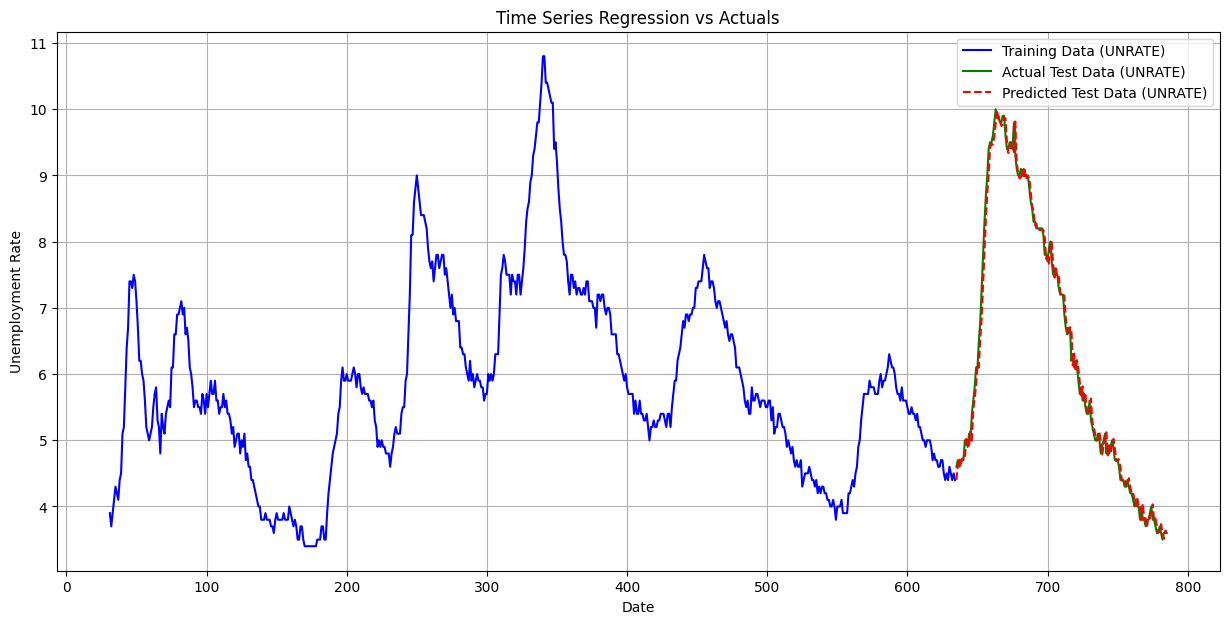

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

plt.plot(y_train.index, y_train, label='Training Data (UNRATE)', color='blue')
plt.plot(y_test.index, y_test, label='Actual Test Data (UNRATE)', color='green')
plt.plot(y_pred_series.index, y_pred_series, label='Predicted Test Data (UNRATE)', color='red', linestyle='--')

plt.title('Time Series Regression vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.grid(True)
plt.show()


## Visualization Summary and Insights

### Summary of the Visualization:
The plot clearly illustrates the model's performance by displaying three distinct series over time:
*   **Training Data (UNRATE)**: The blue line represents the historical UNRATE data used to train the model, covering the period from 1954 to approximately the mid-2000s.
*   **Actual Test Data (UNRATE)**: The green line shows the actual UNRATE values for the test period, which spans from the mid-2000s to the end of the dataset in 2019.
*   **Predicted Test Data (UNRATE)**: The dashed red line represents the model's predictions for the UNRATE during the test period.

The plot visually confirms that the model captures the overall trend of the UNRATE series, with the predicted values closely following the actual test data. There are occasional discrepancies, but the general direction and magnitude of change are well-approximated.

### Insights Gained:
*   **Good Fit**: The visual alignment between the `Actual Test Data (UNRATE)` and `Predicted Test Data (UNRATE)` lines suggests a good fit of the Linear Regression model to the underlying patterns in the unemployment rate data. The model seems to generalize well to unseen data within the observed range.
*   **Lagged Features Effectiveness**: The use of lagged UNRATE values as regressors appears to be an effective strategy for predicting future UNRATE values, as the predictions closely track the actual series. This indicates a strong autoregressive component in the UNRATE time series.
*   **Trend Sign Contribution**: The `Rolling_Trend_Sign` feature likely contributes to capturing directional changes, helping the model anticipate increases or decreases in the UNRATE, although its specific impact is not directly discernible from this plot alone.
*   **Limitations**: While the model performs well, there are instances where the predicted line deviates slightly from the actuals, especially during periods of more volatile changes. This indicates that while the model captures the general trend, it might not perfectly capture all short-term fluctuations or extreme events.


## Final Task

### Subtask:
Summarize the visualization and any insights gained from comparing the training data, actual test data, and predictions.


## Summary:

### Q&A
*   **What insights were gained from comparing the training data, actual test data, and predictions?**
    The visualization indicates a good fit of the Linear Regression model, as predicted values closely align with actual test data, suggesting effective generalization to unseen data. The use of lagged UNRATE values appears to be an effective strategy for prediction, highlighting a strong autoregressive component. However, the model has limitations, as it may not perfectly capture all short-term fluctuations or extreme events, especially during volatile periods.

### Data Analysis Key Findings
*   The `y_pred` NumPy array was successfully converted into a pandas Series, `y_pred_series`, properly aligned with the `y_test` index.
*   A comprehensive plot was generated, clearly displaying the `y_train` series (training data, blue line), `y_test` series (actual test data, green line), and `y_pred_series` (predicted test data, dashed red line).
*   The plot visually confirmed that the model captures the overall trend of the UNRATE series, with the predicted values closely following the actual test data, indicating a good visual alignment.

### Insights or Next Steps
*   The model demonstrates a strong capability to capture the general trend of the UNRATE time series, largely due to the effectiveness of lagged features.
*   Future improvements could focus on enhancing the model's performance during periods of high volatility or sudden changes to better capture short-term fluctuations.


# Residual Analysis
## Tools

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import pandas as pd

def calculate_residuals(y_true, y_pred_series):
    """Calculates residuals from true and predicted values."""
    return y_true - y_pred_series

def plot_residuals_over_time(residuals):
    """Plots residuals as a function of time."""
    plt.figure(figsize=(12, 6))
    plt.plot(residuals.index, residuals, marker='o', linestyle='', alpha=0.6, markersize=4)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Residuals Over Time')
    plt.xlabel('Date')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()

def plot_acf_pacf(residuals, lags=40):
    """Plots the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of residuals."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(residuals.dropna(), lags=lags, ax=axes[0], title='Autocorrelation Function of Residuals')
    plot_pacf(residuals.dropna(), lags=lags, ax=axes[1], title='Partial Autocorrelation Function of Residuals')
    plt.tight_layout()
    plt.show()

def plot_residual_distribution_and_tests(residuals):
    """Plots the distribution and QQ plot of residuals, and performs statistical tests."""
    plt.figure(figsize=(15, 6))

    # Distribution Plot
    plt.subplot(1, 2, 1)
    sns.histplot(residuals.dropna(), kde=True, bins=30)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')

    # QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(residuals.dropna(), dist="norm", plot=plt)
    plt.title('QQ Plot of Residuals')

    plt.tight_layout()
    plt.show()

    # Statistical Tests
    kurtosis_val = stats.kurtosis(residuals.dropna())
    shapiro_wilk_stat, shapiro_wilk_p = stats.shapiro(residuals.dropna())

    print(f"Kurtosis of Residuals: {kurtosis_val:.4f}")
    print(f"Shapiro-Wilk Statistic: {shapiro_wilk_stat:.4f}, p-value: {shapiro_wilk_p:.4f}")


## Execution

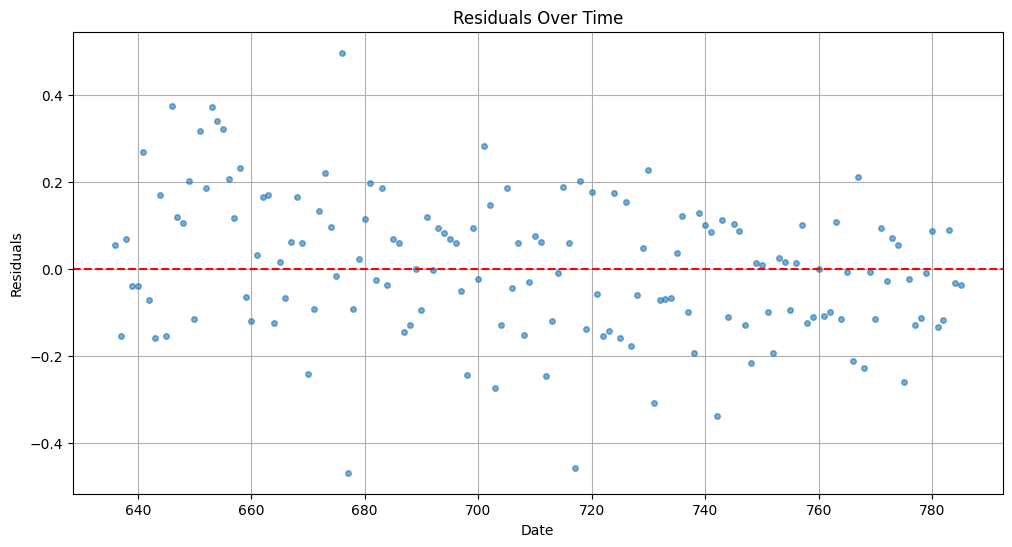

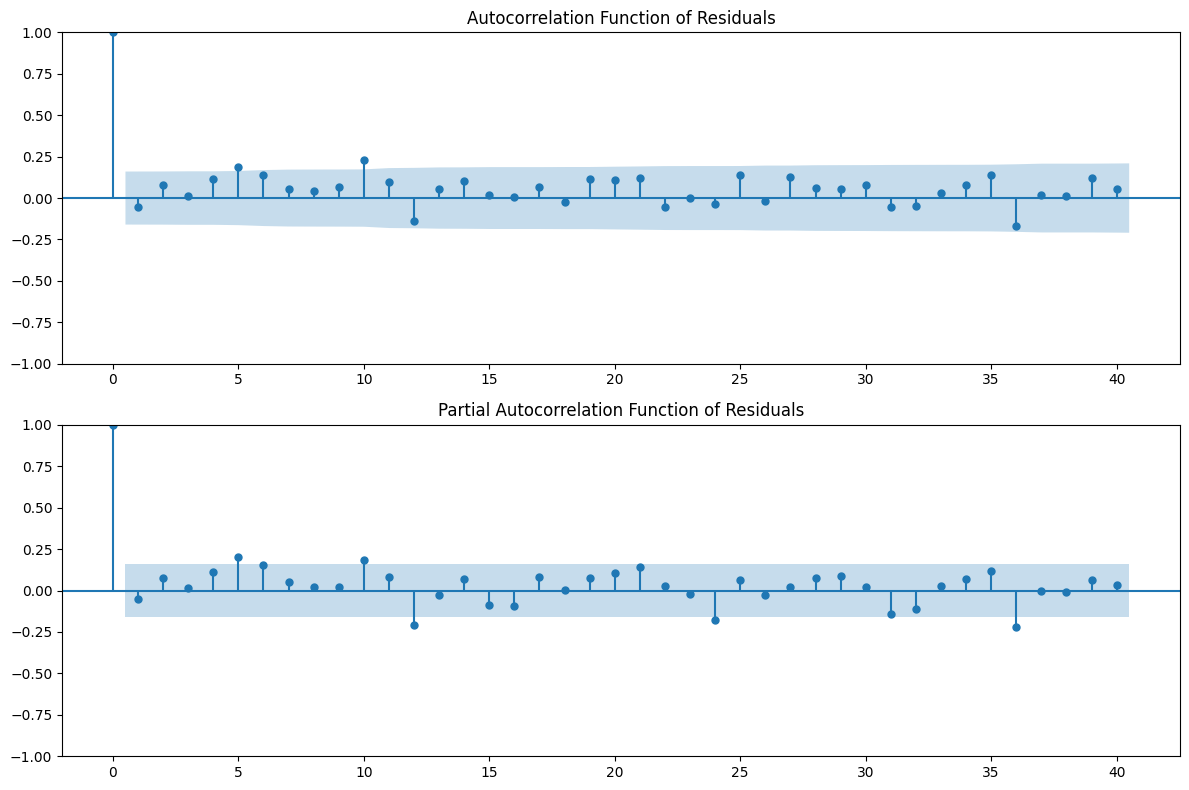

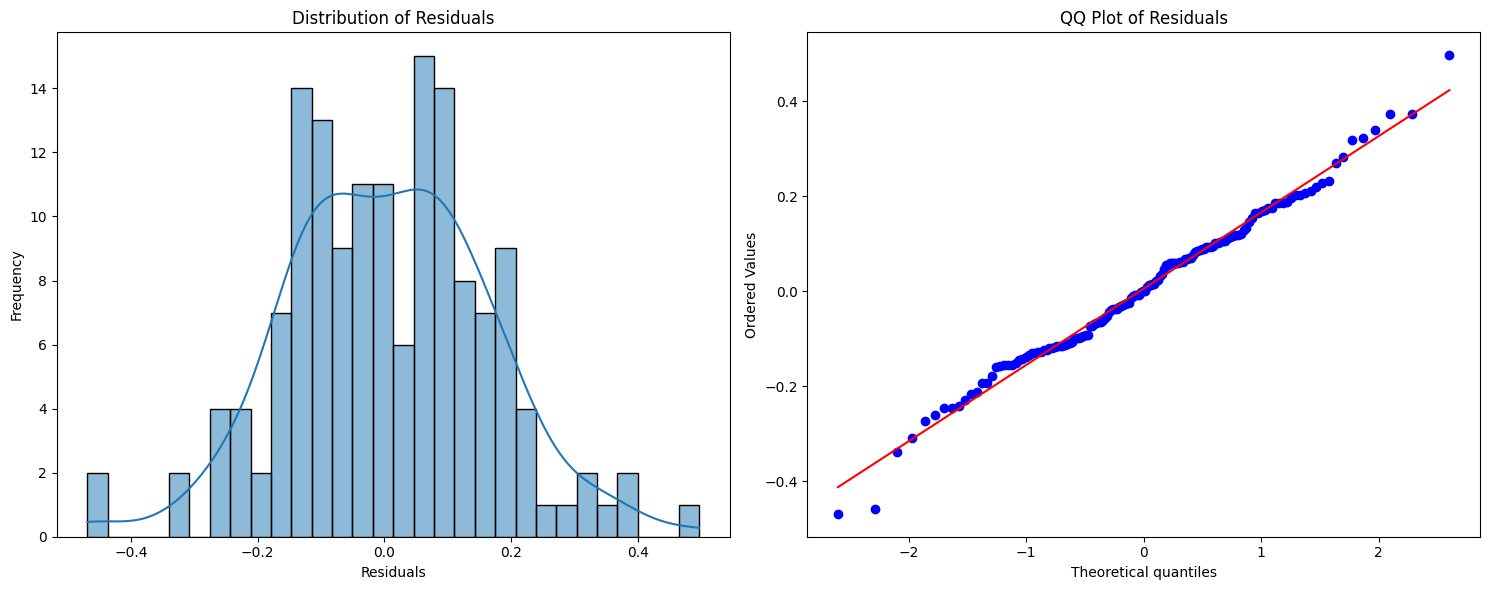

Kurtosis of Residuals: 0.4398
Shapiro-Wilk Statistic: 0.9916, p-value: 0.5225


In [ ]:
# --- Perform Residual Analysis ---

# 1. Calculate residuals
residuals = calculate_residuals(y_test, y_pred_series)

# 2. Plot residuals as a function of time
plot_residuals_over_time(residuals)

# 3. Plot ACF and PACF
plot_acf_pacf(residuals)

# 4. Plot distribution, QQ plot, and compute statistical tests
plot_residual_distribution_and_tests(residuals)